In [8]:
import sys
sys.path.append("/Users/27171653/Desktop/PhD/Specular-Highlights/sh_models")

In [9]:
from pipeline import dhl_generator as dhl_gen
from pipeline import PSDloader as psd_loader
from sh_models import highlight_detector as hd
from sh_models import pconvAE as pc_hr
import matplotlib.pyplot as plt
import torch
from typing import Tuple, Optional
import time
from collections import defaultdict
import torch.nn as nn
import matplotlib.pyplot as plt
from IPython.display import clear_output
from torch.utils.data import DataLoader, Subset


## Highlight Removers Training

In [10]:
diffuse_images = "/Users/27171653/Desktop/PhD/Specular-Highlights/data/train/can/diffuse"
specular_images = "/Users/27171653/Desktop/PhD/Specular-Highlights/data/train/can/glossy"

dataset, loader = psd_loader.make_psd_dataloader(
    diffuse_dir=diffuse_images,
    specular_dir=specular_images,
    batch_size=4,
    soft_gamma=1.0,
    threshold_method="quantile",
    threshold=0.7,
)

small_dataset = Subset(dataset, [6])  # position_06.png for quick testing

small_loader = DataLoader(
    small_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

In [11]:
import time
import random
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from IPython.display import clear_output


def _move_batch_to_device(batch, device):
    out = {}
    for k, v in batch.items():
        out[k] = v.to(device, non_blocking=True) if torch.is_tensor(v) else v
    return out


def _get_loss_fn(loss_name="l1", reduction="mean"):
    loss_name = loss_name.lower()
    if loss_name == "bce":
        return nn.BCELoss(reduction=reduction)
    if loss_name == "l1":
        return nn.L1Loss(reduction=reduction)
    if loss_name == "mse":
        return nn.MSELoss(reduction=reduction)
    if loss_name == "smoothl1":
        return nn.SmoothL1Loss(reduction=reduction)
    raise ValueError("loss_name must be 'bce', 'l1', 'mse', or 'smoothl1'")


def _pick_mask_tensor(batch, mask_source="soft_mask"):
    if mask_source == "mask" and "mask" in batch:
        return batch["mask"]
    if mask_source == "soft_mask" and "soft_mask" in batch:
        return batch["soft_mask"]
    if "mask" in batch:
        return batch["mask"]
    if "soft_mask" in batch:
        return batch["soft_mask"]
    raise KeyError("Batch must contain either 'mask' or 'soft_mask'.")


def _dilate_binary_mask(mask, kernel_size=3):
    if kernel_size <= 1:
        return mask
    pad = kernel_size // 2
    return F.max_pool2d(mask, kernel_size=kernel_size, stride=1, padding=pad)


def _prepare_inpainting_masks(
    batch,
    *,
    mask_source="soft_mask",
    valid_threshold=0.95,
    hole_dilate_kernel=1,
):
    # Use the raw soft validity map to define the binary hole.
    # batch["mask"] is already blurred/feathered and is better suited to weighting than hole carving.
    raw_valid_mask = _pick_mask_tensor(batch, mask_source).float().clamp(0.0, 1.0)
    valid_mask = (raw_valid_mask >= valid_threshold).float()
    hole_mask = 1.0 - valid_mask

    if hole_dilate_kernel > 1:
        hole_mask = (_dilate_binary_mask(hole_mask, kernel_size=hole_dilate_kernel) > 0).float()
        valid_mask = 1.0 - hole_mask

    return raw_valid_mask, valid_mask, hole_mask


def _masked_mean(pixel_values, mask, eps=1e-8):
    if pixel_values.ndim != 4:
        raise ValueError(f"Expected pixel_values [B,C,H,W], got {tuple(pixel_values.shape)}")
    if mask.ndim != 4:
        raise ValueError(f"Expected mask [B,1,H,W], got {tuple(mask.shape)}")

    if mask.shape[1] != 1:
        mask = mask.mean(dim=1, keepdim=True)

    denom = mask.sum() * pixel_values.shape[1]
    return (pixel_values * mask).sum() / (denom + eps)


def _forward_highlight_removal_model(model, x_masked, valid_mask, hole_mask, context_map=None, soft_mask=None):
    try:
        hole_pred = model(
            x_masked,
            valid_mask=valid_mask,
            hole_mask=hole_mask,
            context_map=context_map,
            soft_mask=soft_mask,
        )
    except TypeError:
        try:
            hole_pred = model(x_masked, valid_mask=valid_mask, hole_mask=hole_mask)
        except TypeError:
            hole_pred = model(x_masked, valid_mask)

    if hole_pred.shape != x_masked.shape:
        raise ValueError(
            f"Prediction and masked input shapes must match, got {tuple(hole_pred.shape)} and {tuple(x_masked.shape)}"
        )

    return hole_pred


def _run_highlight_removal_batch(
    model,
    batch,
    pixel_loss_fn,
    *,
    mask_source="soft_mask",
    valid_threshold=0.95,
    hole_dilate_kernel=1,
    context_weight=0.05,
):
    x = batch["input"].float()
    y_true = batch["target"].float()

    if x.ndim != 4 or x.shape[1] != 3:
        raise ValueError(f"Expected input shape [B,3,H,W], got {tuple(x.shape)}")
    if y_true.ndim != 4 or y_true.shape[1] != 3:
        raise ValueError(f"Expected target shape [B,3,H,W], got {tuple(y_true.shape)}")

    raw_valid_mask, valid_mask, hole_mask = _prepare_inpainting_masks(
        batch,
        mask_source=mask_source,
        valid_threshold=valid_threshold,
        hole_dilate_kernel=hole_dilate_kernel,
    )

    context_map = None
    if "depth_map" in batch:
        context_map = batch["depth_map"].float()
    elif "context_map" in batch:
        context_map = batch["context_map"].float()

    x_masked = x * valid_mask
    hole_pred = _forward_highlight_removal_model(
        model,
        x_masked,
        valid_mask,
        hole_mask,
        context_map=context_map,
        soft_mask=raw_valid_mask,
    )
    y_pred = x * valid_mask + hole_pred * hole_mask

    pixel_loss = pixel_loss_fn(y_pred, y_true)
    hole_opt_loss = _masked_mean(pixel_loss, hole_mask)
    context_opt_loss = _masked_mean(pixel_loss, valid_mask)
    total_loss = hole_opt_loss + context_weight * context_opt_loss

    abs_err = (y_pred - y_true).abs()
    hole_l1 = _masked_mean(abs_err, hole_mask)
    context_l1 = _masked_mean(abs_err, valid_mask)
    full_l1 = abs_err.mean()
    identity_hole_l1 = _masked_mean((x - y_true).abs(), hole_mask)

    return {
        "x": x,
        "y_true": y_true,
        "x_masked": x_masked,
        "raw_valid_mask": raw_valid_mask,
        "valid_mask": valid_mask,
        "hole_mask": hole_mask,
        "hole_pred": hole_pred,
        "y_pred": y_pred,
        "loss": total_loss,
        "hole_opt_loss": hole_opt_loss,
        "context_opt_loss": context_opt_loss,
        "hole_l1": hole_l1,
        "context_l1": context_l1,
        "full_l1": full_l1,
        "identity_hole_l1": identity_hole_l1,
    }


@torch.no_grad()
def evaluate_highlight_removal_rgb(
    model,
    loader,
    *,
    loss_name,
    device,
    mask_source="soft_mask",
    valid_threshold=0.95,
    hole_dilate_kernel=1,
    context_weight=0.05,
):
    model.eval()
    pixel_loss_fn = _get_loss_fn(loss_name, reduction="none")
    running = defaultdict(float)
    n_samples = 0

    for batch in loader:
        batch = _move_batch_to_device(batch, device)
        outputs = _run_highlight_removal_batch(
            model,
            batch,
            pixel_loss_fn,
            mask_source=mask_source,
            valid_threshold=valid_threshold,
            hole_dilate_kernel=hole_dilate_kernel,
            context_weight=context_weight,
        )

        bs = outputs["x"].shape[0]
        n_samples += bs
        for key in ("loss", "hole_opt_loss", "context_opt_loss", "hole_l1", "context_l1", "full_l1", "identity_hole_l1"):
            running[key] += outputs[key].item() * bs

    return {key: value / max(n_samples, 1) for key, value in running.items()}


@torch.no_grad()
def show_rgb_predictions(
    model,
    dataset,
    device,
    *,
    n_show=3,
    seed=None,
    mask_source="soft_mask",
    valid_threshold=0.95,
    hole_dilate_kernel=1,
    context_weight=0.05,
):
    if seed is not None:
        random.seed(seed)

    n_show = min(n_show, len(dataset))
    indices = random.sample(range(len(dataset)), n_show)
    pixel_loss_fn = _get_loss_fn("l1", reduction="none")

    model.eval()
    fig, axes = plt.subplots(n_show, 6, figsize=(24, 4 * n_show))
    if n_show == 1:
        axes = axes[None, :]

    for row, idx in enumerate(indices):
        sample = dataset[idx]
        batch = {
            k: (v.unsqueeze(0) if torch.is_tensor(v) else v)
            for k, v in sample.items()
        }
        batch = _move_batch_to_device(batch, device)

        outputs = _run_highlight_removal_batch(
            model,
            batch,
            pixel_loss_fn,
            mask_source=mask_source,
            valid_threshold=valid_threshold,
            hole_dilate_kernel=hole_dilate_kernel,
            context_weight=context_weight,
        )

        inp = outputs["x"][0].detach().cpu().permute(1, 2, 0).clamp(0, 1)
        masked_inp = outputs["x_masked"][0].detach().cpu().permute(1, 2, 0).clamp(0, 1)
        target = outputs["y_true"][0].detach().cpu().permute(1, 2, 0).clamp(0, 1)
        hole_mask = outputs["hole_mask"][0, 0].detach().cpu()
        pred = outputs["y_pred"][0].detach().cpu().permute(1, 2, 0).clamp(0, 1)
        abs_err = (outputs["y_pred"][0].detach().cpu() - sample["target"].cpu()).abs().mean(dim=0)

        axes[row, 0].imshow(inp)
        axes[row, 0].set_title(f"Input\n{sample['name']}")
        axes[row, 0].axis("off")

        axes[row, 1].imshow(masked_inp)
        axes[row, 1].set_title("Masked input")
        axes[row, 1].axis("off")

        axes[row, 2].imshow(target)
        axes[row, 2].set_title("Ground truth RGB")
        axes[row, 2].axis("off")

        axes[row, 3].imshow(hole_mask, cmap="gray", vmin=0, vmax=1)
        axes[row, 3].set_title("Hole mask")
        axes[row, 3].axis("off")

        axes[row, 4].imshow(pred)
        axes[row, 4].set_title(
            f"Prediction RGB\n"
        )
        axes[row, 4].axis("off")

        axes[row, 5].imshow(abs_err, cmap="gray", vmin=0, vmax=1)
        axes[row, 5].set_title("Mean abs error")
        axes[row, 5].axis("off")

    plt.tight_layout()
    plt.show()


In [12]:
def train_highlight_removal_autoencoder(
    train_loader,
    val_loader=None,
    *,
    in_channels=3,
    out_channels=3,
    base_features=64,
    depth=4,
    max_features=512,
    bottleneck_blocks=2,
    use_conv_shift=False,
    lr=1e-3,
    weight_decay=0.0,
    epochs=20,
    device=None,
    loss_name="l1",
    grad_clip=None,
    plot_every=1,
    preview_dataset=None,
    preview_every=0,
    save_best_path=None,
    mask_source="soft_mask",
    valid_threshold=0.95,
    hole_dilate_kernel=1,
    context_weight=0.05,
):
    """
    Train RGB highlight removal as masked inpainting.

    The model receives an input where masked pixels are removed, predicts RGB for the
    whole image, and the final output is composited so only the hole region changes.
    """
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")

    model = pc_hr.HighlightRemovalAutoencoder(
        in_channels=in_channels,
        out_channels=out_channels,
        base_features=base_features,
        depth=depth,
        max_features=max_features,
        bottleneck_blocks=bottleneck_blocks,
        use_conv_shift=use_conv_shift,
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay,
    )
    pixel_loss_fn = _get_loss_fn(loss_name, reduction="none")

    history = defaultdict(list)
    best_score = float("inf")
    start_time = time.time()

    def _save_checkpoint(path, epoch, train_metrics, val_metrics=None):
        ckpt = {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "train_metrics": train_metrics,
            "config": {
                "in_channels": in_channels,
                "out_channels": out_channels,
                "base_features": base_features,
                "depth": depth,
                "max_features": max_features,
                "bottleneck_blocks": bottleneck_blocks,
                "use_conv_shift": use_conv_shift,
                "lr": lr,
                "weight_decay": weight_decay,
                "loss_name": loss_name,
                "mask_source": mask_source,
                "valid_threshold": valid_threshold,
                "hole_dilate_kernel": hole_dilate_kernel,
                "context_weight": context_weight,
            },
        }
        if val_metrics is not None:
            ckpt["val_metrics"] = val_metrics
        torch.save(ckpt, path)

    for epoch in range(1, epochs + 1):
        model.train()
        running = defaultdict(float)
        n_samples = 0

        for batch in train_loader:
            batch = _move_batch_to_device(batch, device)
            optimizer.zero_grad(set_to_none=True)

            outputs = _run_highlight_removal_batch(
                model,
                batch,
                pixel_loss_fn,
                mask_source=mask_source,
                valid_threshold=valid_threshold,
                hole_dilate_kernel=hole_dilate_kernel,
                context_weight=context_weight,
            )
            loss = outputs["loss"]
            loss.backward()

            if grad_clip is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

            optimizer.step()

            bs = outputs["x"].shape[0]
            n_samples += bs
            for key in ("loss", "hole_opt_loss", "context_opt_loss", "hole_l1", "context_l1", "full_l1", "identity_hole_l1"):
                running[key] += outputs[key].item() * bs

        train_metrics = {key: value / max(n_samples, 1) for key, value in running.items()}
        history["train_loss"].append(train_metrics["loss"])
        history["train_hole_opt_loss"].append(train_metrics["hole_opt_loss"])
        history["train_context_opt_loss"].append(train_metrics["context_opt_loss"])
        history["train_hole_l1"].append(train_metrics["hole_l1"])
        history["train_context_l1"].append(train_metrics["context_l1"])
        history["train_full_l1"].append(train_metrics["full_l1"])
        history["train_identity_hole_l1"].append(train_metrics["identity_hole_l1"])
        history["lr"].append(optimizer.param_groups[0]["lr"])

        val_metrics = None
        monitor_score = train_metrics["loss"]
        if val_loader is not None:
            val_metrics = evaluate_highlight_removal_rgb(
                model=model,
                loader=val_loader,
                loss_name=loss_name,
                device=device,
                mask_source=mask_source,
                valid_threshold=valid_threshold,
                hole_dilate_kernel=hole_dilate_kernel,
                context_weight=context_weight,
            )
            history["val_loss"].append(val_metrics["loss"])
            history["val_hole_opt_loss"].append(val_metrics["hole_opt_loss"])
            history["val_context_opt_loss"].append(val_metrics["context_opt_loss"])
            history["val_hole_l1"].append(val_metrics["hole_l1"])
            history["val_context_l1"].append(val_metrics["context_l1"])
            history["val_full_l1"].append(val_metrics["full_l1"])
            history["val_identity_hole_l1"].append(val_metrics["identity_hole_l1"])
            monitor_score = val_metrics["loss"]

        if monitor_score < best_score:
            best_score = monitor_score
            if save_best_path is not None:
                _save_checkpoint(
                    path=save_best_path,
                    epoch=epoch,
                    train_metrics=train_metrics,
                    val_metrics=val_metrics,
                )

        if (epoch % plot_every == 0) or (epoch == 1) or (epoch == epochs):
            clear_output(wait=True)

            plt.figure(figsize=(8, 5))
            plt.plot(history["train_loss"], label="Train total loss")
            if history.get("val_loss"):
                plt.plot(history["val_loss"], label="Val total loss")
            plt.xlabel("Epoch")
            plt.ylabel("Masked reconstruction loss")
            plt.title(f"RGB highlight removal loss, epoch {epoch}/{epochs}")
            plt.grid(True, alpha=0.3)
            plt.legend()
            plt.tight_layout()
            plt.show()

            elapsed_min = (time.time() - start_time) / 60.0
            msg = (
                f"Epoch {epoch}/{epochs} | train loss: {train_metrics['loss']:.6f} | "
            )
            if val_metrics is not None:
                msg += (
                    f" | val loss: {val_metrics['loss']:.6f} | "
                    f"val hole L1: {val_metrics['hole_l1']:.6f}"
                )
            msg += f" | elapsed: {elapsed_min:.1f} min"
            print(msg)

        if (
            preview_dataset is not None
            and preview_every > 0
            and ((epoch % preview_every == 0) or (epoch == epochs))
        ):
            show_rgb_predictions(
                model=model,
                dataset=preview_dataset,
                device=device,
                n_show=3,
                mask_source=mask_source,
                valid_threshold=valid_threshold,
                hole_dilate_kernel=hole_dilate_kernel,
                context_weight=context_weight,
            )

    return model, dict(history)


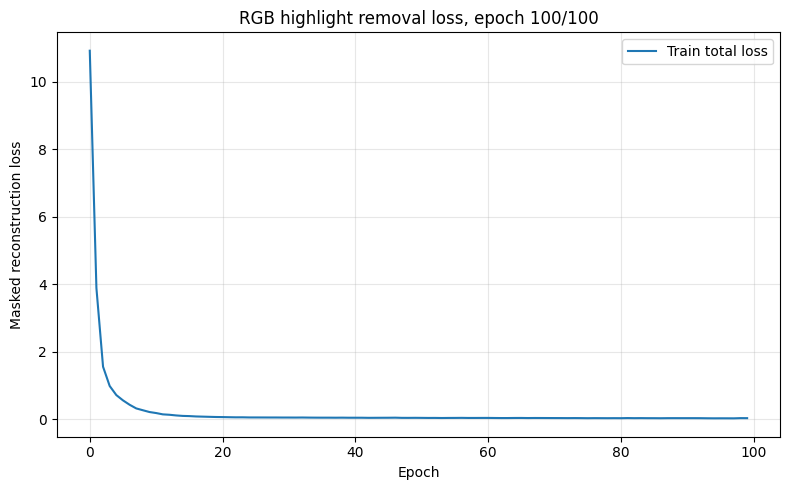

Epoch 100/100 | train loss: 0.031568 |  | elapsed: 7.4 min


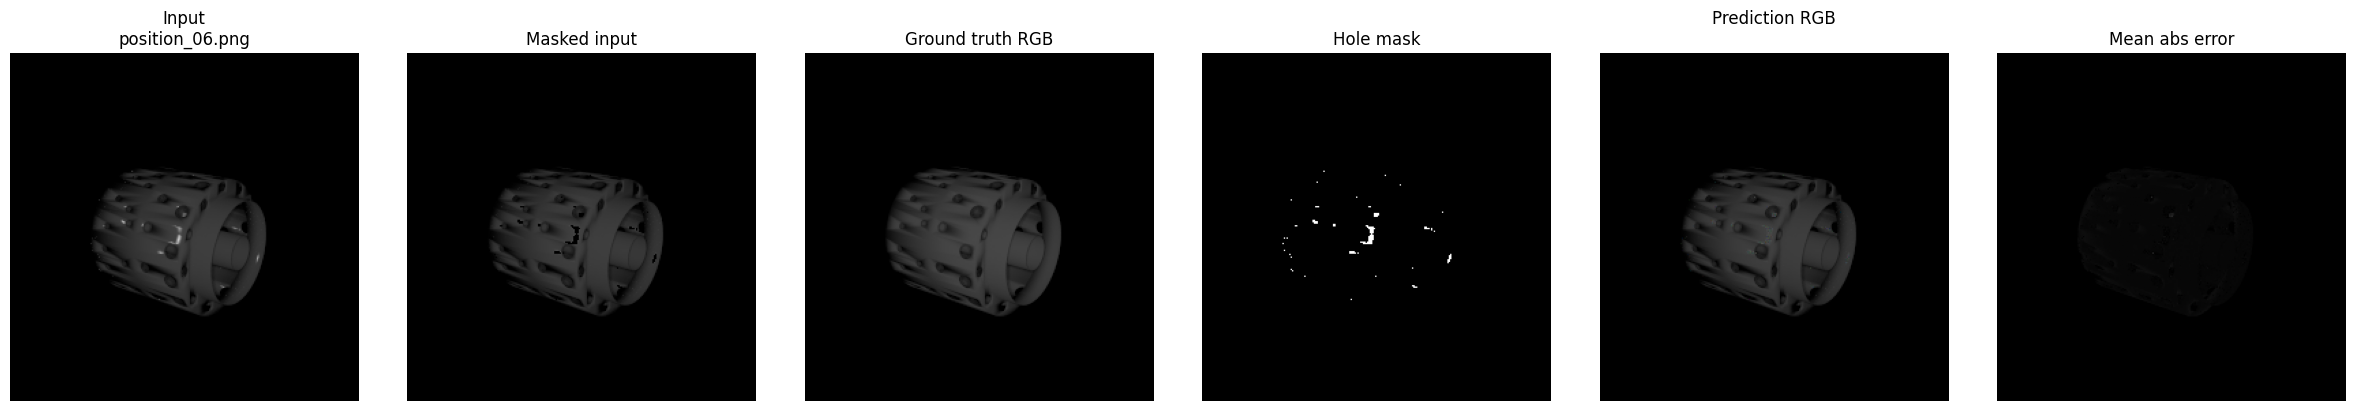

In [13]:
model, history = train_highlight_removal_autoencoder(
    train_loader=loader,
    val_loader=None,
    in_channels=3,
    out_channels=3,
    use_conv_shift=False,
    epochs=100,
    device="cpu",
    loss_name="l1",
    preview_dataset=small_dataset,
    preview_every=20,
    save_best_path="weights/best_highlight_removal_rgb.pth",
    mask_source="soft_mask",
    valid_threshold=0.95,
    hole_dilate_kernel=1,
    context_weight=0.05,
)


In [14]:
#Train and preview the custom RGB models on the small can sample

from pathlib import Path
import importlib
import torch.nn.functional as F

three_channel_unet = importlib.import_module("3chanelunet")
prepo_pd_resnet = importlib.reload(importlib.import_module("prepo.models.pd_resnet"))

TEST_EPOCHS = 100
test_device = "cuda" if torch.cuda.is_available() else "cpu"
weights_dir = Path("weights")
weights_dir.mkdir(parents=True, exist_ok=True)


def train_custom_rgb_model(
    model,
    train_loader,
    val_loader=None,
    *,
    lr=1e-3,
    weight_decay=0.0,
    epochs=TEST_EPOCHS,
    device=None,
    loss_name="l1",
    grad_clip=None,
    log_every=10,
    plot_every=None,
    preview_dataset=None,
    save_best_path=None,
    model_label="RGB model",
    mask_source="soft_mask",
    valid_threshold=0.95,
    hole_dilate_kernel=1,
    context_weight=0.05,
):
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    plot_every = plot_every or epochs
    model = model.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    pixel_loss_fn = _get_loss_fn(loss_name, reduction="none")

    history = defaultdict(list)
    best_loss = float("inf")
    start_time = time.time()

    for epoch in range(1, epochs + 1):
        model.train()
        running = defaultdict(float)
        n_samples = 0

        for batch in train_loader:
            batch = _move_batch_to_device(batch, device)
            optimizer.zero_grad(set_to_none=True)

            outputs = _run_highlight_removal_batch(
                model,
                batch,
                pixel_loss_fn,
                mask_source=mask_source,
                valid_threshold=valid_threshold,
                hole_dilate_kernel=hole_dilate_kernel,
                context_weight=context_weight,
            )
            loss = outputs["loss"]
            loss.backward()

            if grad_clip is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

            optimizer.step()

            bs = outputs["x"].shape[0]
            n_samples += bs
            for key in ("loss", "hole_opt_loss", "context_opt_loss", "hole_l1", "context_l1", "full_l1", "identity_hole_l1"):
                running[key] += outputs[key].item() * bs

        train_metrics = {key: value / max(n_samples, 1) for key, value in running.items()}
        history["train_loss"].append(train_metrics["loss"])
        history["train_hole_opt_loss"].append(train_metrics["hole_opt_loss"])
        history["train_context_opt_loss"].append(train_metrics["context_opt_loss"])
        history["train_hole_l1"].append(train_metrics["hole_l1"])
        history["train_context_l1"].append(train_metrics["context_l1"])
        history["train_full_l1"].append(train_metrics["full_l1"])
        history["train_identity_hole_l1"].append(train_metrics["identity_hole_l1"])
        history["lr"].append(optimizer.param_groups[0]["lr"])

        val_metrics = None
        monitor_loss = train_metrics["loss"]
        if val_loader is not None:
            val_metrics = evaluate_highlight_removal_rgb(
                model=model,
                loader=val_loader,
                loss_name=loss_name,
                device=device,
                mask_source=mask_source,
                valid_threshold=valid_threshold,
                hole_dilate_kernel=hole_dilate_kernel,
                context_weight=context_weight,
            )
            history["val_loss"].append(val_metrics["loss"])
            history["val_hole_opt_loss"].append(val_metrics["hole_opt_loss"])
            history["val_context_opt_loss"].append(val_metrics["context_opt_loss"])
            history["val_hole_l1"].append(val_metrics["hole_l1"])
            history["val_context_l1"].append(val_metrics["context_l1"])
            history["val_full_l1"].append(val_metrics["full_l1"])
            history["val_identity_hole_l1"].append(val_metrics["identity_hole_l1"])
            monitor_loss = val_metrics["loss"]

        if monitor_loss < best_loss:
            best_loss = monitor_loss
            if save_best_path is not None:
                torch.save(
                    {
                        "epoch": epoch,
                        "model_state_dict": model.state_dict(),
                        "optimizer_state_dict": optimizer.state_dict(),
                        "train_metrics": train_metrics,
                        "val_metrics": val_metrics,
                        "config": {
                            "loss_name": loss_name,
                            "mask_source": mask_source,
                            "valid_threshold": valid_threshold,
                            "hole_dilate_kernel": hole_dilate_kernel,
                            "context_weight": context_weight,
                        },
                    },
                    save_best_path,
                )

        if log_every and ((epoch % log_every == 0) or (epoch == 1) or (epoch == epochs)):
            elapsed = time.time() - start_time
            msg = (
                f"{model_label} | epoch {epoch:03d}/{epochs} | loss {train_metrics['loss']:.6f} | "
                f"hole L1 {train_metrics['hole_l1']:.6f} | identity hole L1 {train_metrics['identity_hole_l1']:.6f} | "
                f"best {best_loss:.6f} | elapsed {elapsed:.1f}s"
            )
            if val_metrics is not None:
                msg += f" | val loss {val_metrics['loss']:.6f}"
            print(msg)

        if epoch % plot_every == 0 or epoch == epochs:
            clear_output(wait=True)
            plt.figure(figsize=(8, 5))
            plt.plot(history["train_loss"], label="Train total loss")
            if history.get("val_loss"):
                plt.plot(history["val_loss"], label="Val total loss")
            plt.xlabel("Epoch")
            plt.ylabel("Masked reconstruction loss")
            plt.title(f"{model_label} loss")
            plt.grid(True, alpha=0.3)
            plt.legend()
            plt.tight_layout()
            plt.show()

    if preview_dataset is not None and len(preview_dataset) > 0:
        show_rgb_predictions(
            model=model,
            dataset=preview_dataset,
            device=device,
            n_show=1,
            seed=0,
            mask_source=mask_source,
            valid_threshold=valid_threshold,
            hole_dilate_kernel=hole_dilate_kernel,
            context_weight=context_weight,
        )

    return model, dict(history)


class _PDResNetDecoderBlock(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels):
        super().__init__()
        self.up = nn.Sequential(
            nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False),
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

        fused_channels = out_channels + skip_channels
        self.fuse = nn.Sequential(
            nn.Conv2d(fused_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x, skip=None):
        x = self.up(x)
        if skip is not None:
            if x.shape[-2:] != skip.shape[-2:]:
                x = F.interpolate(x, size=skip.shape[-2:], mode="bilinear", align_corners=False)
            x = torch.cat([x, skip], dim=1)
        return self.fuse(x)


class PrepoPDResNetReconstructor(nn.Module):
    def __init__(self, out_channels=3):
        super().__init__()
        self.backbone = prepo_pd_resnet.pdresnet18(pretrained=False, num_classes=out_channels)

        self.dec4 = _PDResNetDecoderBlock(512, 256, 256)
        self.dec3 = _PDResNetDecoderBlock(256, 128, 128)
        self.dec2 = _PDResNetDecoderBlock(128, 64, 64)
        self.dec1 = _PDResNetDecoderBlock(64, 64, 64)
        self.dec0 = _PDResNetDecoderBlock(64, 0, 32)
        self.out = nn.Conv2d(32, out_channels, kernel_size=1)

    def forward(self, x, valid_mask=None, hole_mask=None):
        if valid_mask is None:
            raise ValueError("PrepoPDResNetReconstructor requires a validity mask for partial-conv propagation.")

        (stem, enc1, enc2, enc3, enc4), _ = self.backbone.forward_encoder(x, valid_mask)

        y = self.dec4(enc4, enc3)
        y = self.dec3(y, enc2)
        y = self.dec2(y, enc1)
        y = self.dec1(y, stem)
        y = self.dec0(y)

        if y.shape[-2:] != x.shape[-2:]:
            y = F.interpolate(y, size=x.shape[-2:], mode="bilinear", align_corners=False)

        return self.out(y)


class ThreeChannelUNetAdapter(nn.Module):
    def __init__(
        self,
        *,
        in_channels=3,
        base_channels=16,
        depth=3,
        out_channels=3,
        bottleneck_length=1,
        num_heads=4,
        use_bottleneck_context=False,
        use_bottleneck_self_attention=True,
        use_soft_mask_input=False,
        context_channels=1,
    ):
        super().__init__()
        self.use_bottleneck_context = use_bottleneck_context
        self.use_bottleneck_self_attention = use_bottleneck_self_attention
        self.use_soft_mask_input = use_soft_mask_input
        self.model = three_channel_unet.UNet(
            in_channels=in_channels + (1 if use_soft_mask_input else 0),
            base_channels=base_channels,
            depth=depth,
            out_channels=out_channels,
            Attention=(
                three_channel_unet.TransformerEncoderCA
                if use_bottleneck_context
                else (three_channel_unet.TransformerEncoderSA if use_bottleneck_self_attention else None)
            ),
            OnlyonBottleneck=(use_bottleneck_context or use_bottleneck_self_attention),
            context_channels=context_channels,
            num_heads=num_heads,
            bottleneck_length=bottleneck_length,
        )

    def forward(self, x, valid_mask=None, hole_mask=None, context_map=None, soft_mask=None):
        if self.use_soft_mask_input:
            if soft_mask is None:
                raise ValueError("ThreeChannelUNetAdapter with use_soft_mask_input=True requires soft_mask.")
            corruption_map = 1.0 - soft_mask
            x = torch.cat([x, corruption_map], dim=1)

        if not self.use_bottleneck_context:
            return self.model(x)

        if context_map is None:
            raise ValueError(
                "ThreeChannelUNetAdapter was created with use_bottleneck_context=True but no context_map was provided."
            )

        return self.model(x, context=context_map)




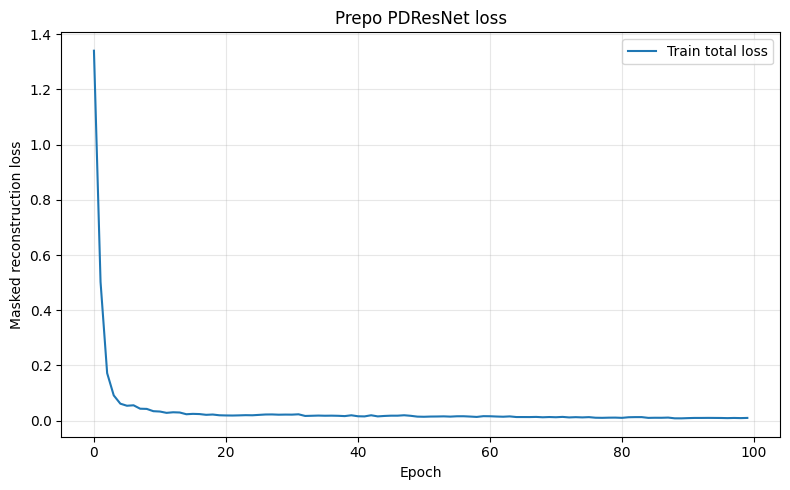

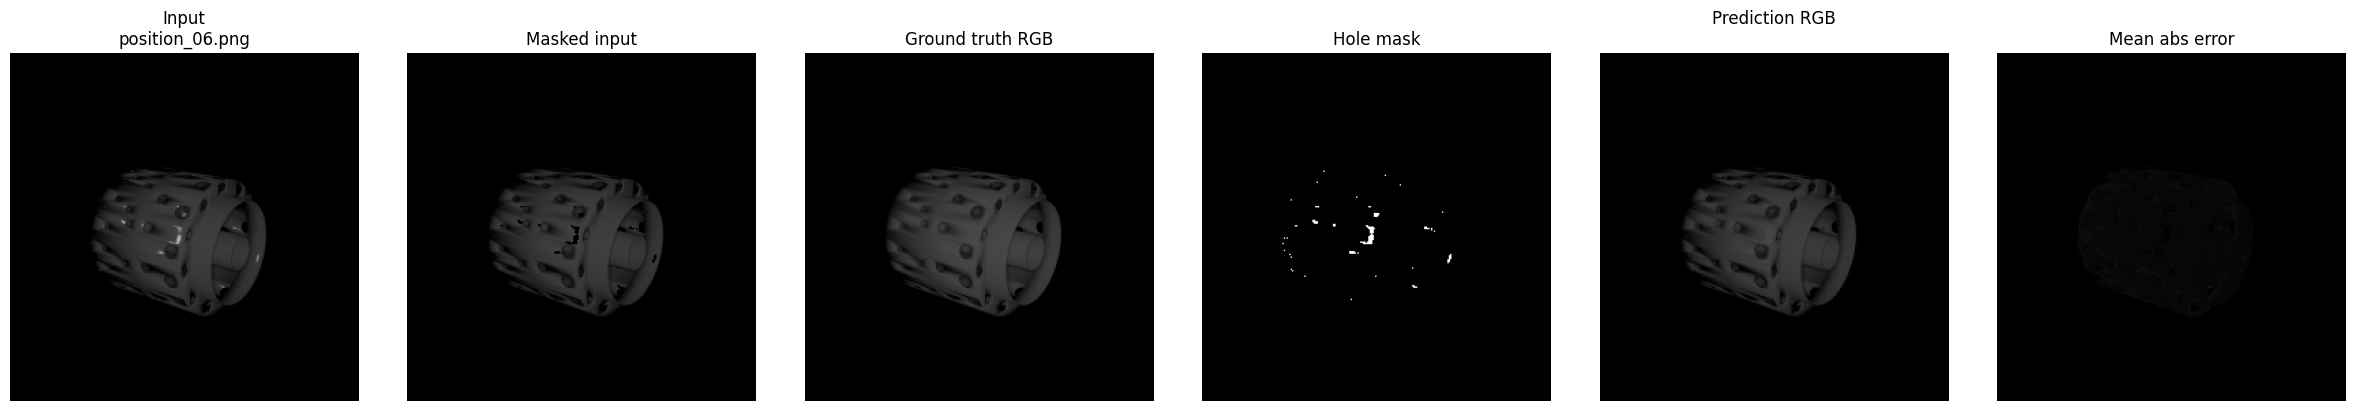

Final prepo pdresnet train loss: 0.009510


In [15]:
pdresnet_model, pdresnet_history = train_custom_rgb_model(
    model=PrepoPDResNetReconstructor(out_channels=3),
    train_loader=loader,
    lr=1e-3,
    epochs=TEST_EPOCHS,
    device=test_device,
    loss_name="l1",
    log_every=10,
    plot_every=TEST_EPOCHS,
    preview_dataset=small_dataset,
    save_best_path=str(weights_dir / "prepo_pdresnet_rgb.pth"),
    model_label="Prepo PDResNet",
    mask_source="soft_mask",
    valid_threshold=0.95,
    hole_dilate_kernel=1,
    context_weight=0.05,
)

print(f"Final prepo pdresnet train loss: {pdresnet_history['train_loss'][-1]:.6f}")


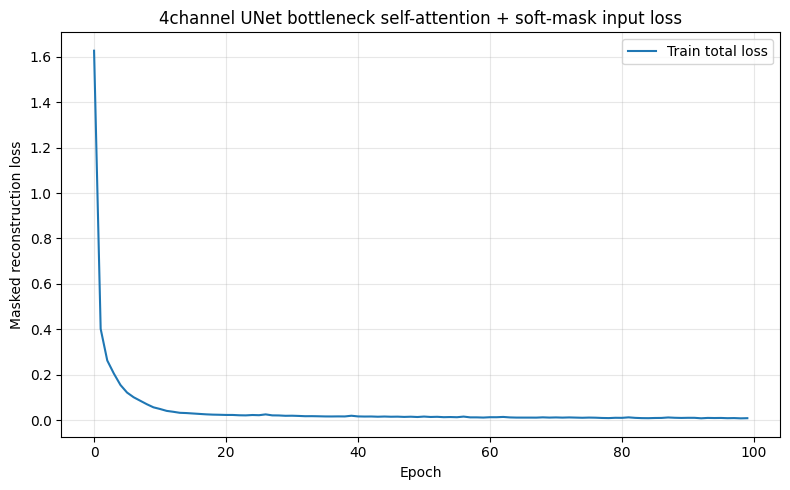

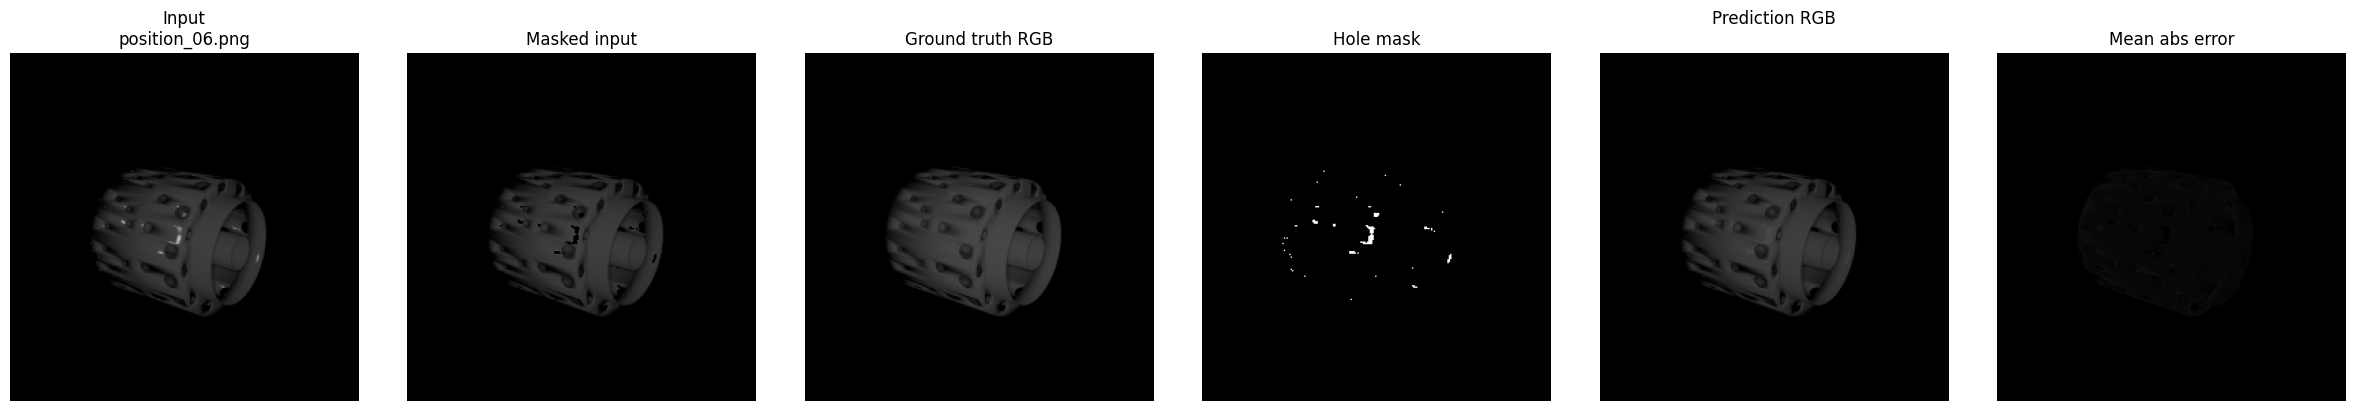

Final 4channel UNet bottleneck self-attention + soft-mask input train loss: 0.008464


In [16]:
# Train and preview the 4-channel unet with bottleneck self-attention and a concatenated soft-mask channel.
# This keeps the inpainting setup but appends 1 - soft_mask as a fourth input channel.
# Set use_bottleneck_context=True later when a 1-channel depth map is available.

unet4_model, unet4_history = train_custom_rgb_model(
    model=ThreeChannelUNetAdapter(
        in_channels=3,
        base_channels=16,
        depth=3,
        out_channels=3,
        bottleneck_length=1,
        use_soft_mask_input=True,
    ),
    train_loader=loader,
    lr=1e-3,
    epochs=TEST_EPOCHS,
    device=test_device,
    loss_name="l1",
    log_every=10,
    plot_every=TEST_EPOCHS,
    preview_dataset=small_dataset,
    save_best_path=str(weights_dir / "3channel_unet_bottleneck_self_attention_softmask_rgb.pth"),
    model_label="4channel UNet bottleneck self-attention + soft-mask input",
    mask_source="soft_mask",
    valid_threshold=0.95,
    hole_dilate_kernel=1,
    context_weight=0.05,
)

print(f"Final 4channel UNet bottleneck self-attention + soft-mask input train loss: {unet4_history['train_loss'][-1]:.6f}")


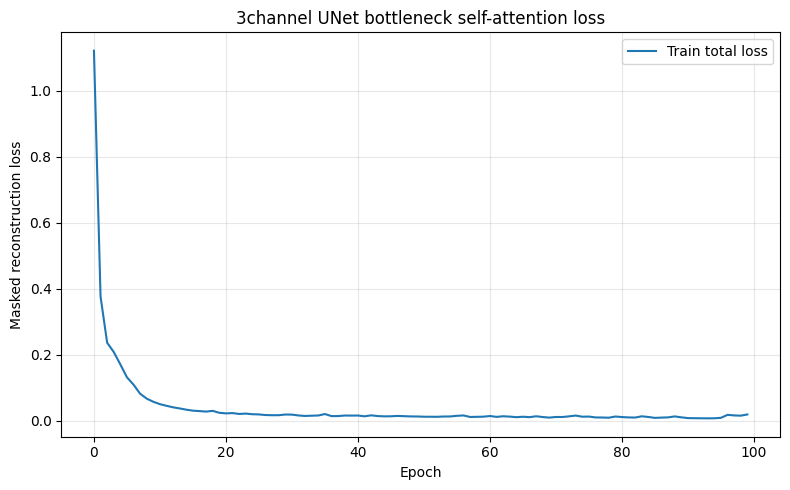

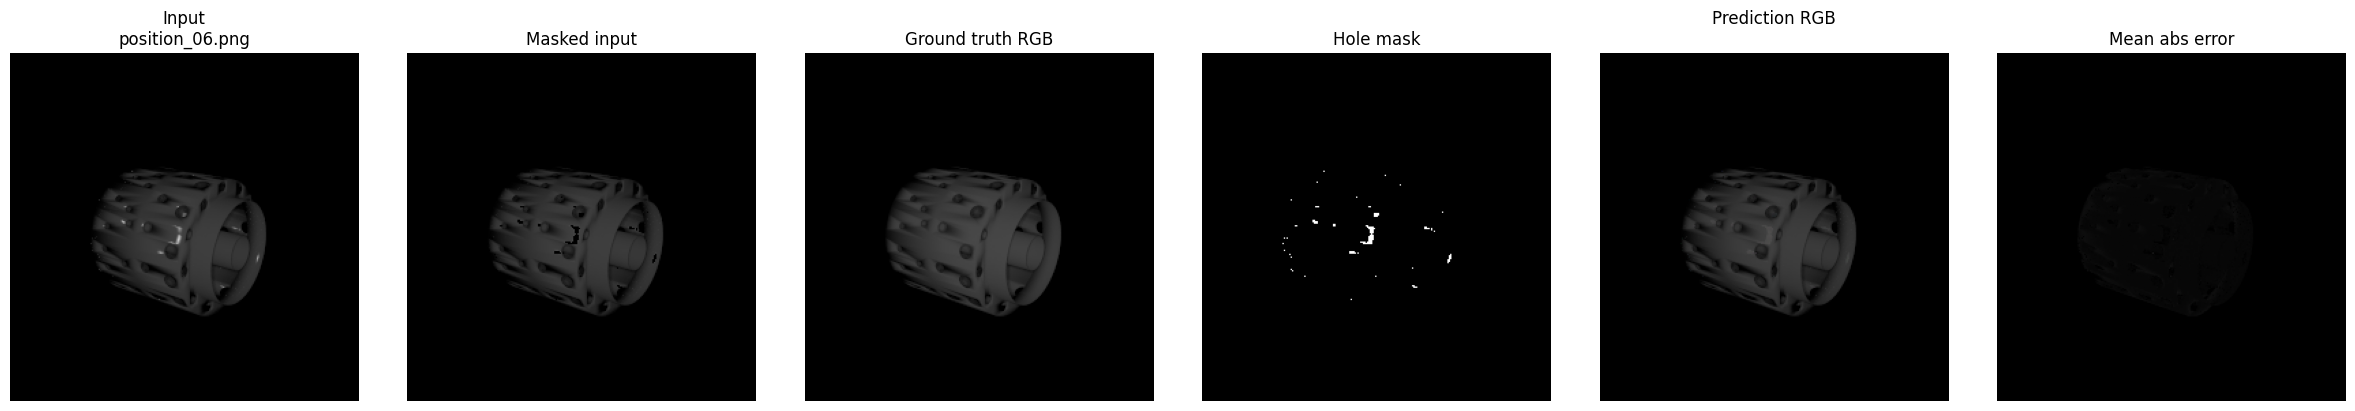

Final 3channel UNet bottleneck self-attention train loss: 0.019409


In [17]:
# Train and preview the original 3-channel unet with bottleneck self-attention only.
# This preserves the previous U-Net settings without concatenating the soft mask.

unet3_model, unet3_history = train_custom_rgb_model(
    model=ThreeChannelUNetAdapter(
        in_channels=3,
        base_channels=16,
        depth=3,
        out_channels=3,
        bottleneck_length=1,
        use_soft_mask_input=False,
    ),
    train_loader=loader,
    lr=1e-3,
    epochs=TEST_EPOCHS,
    device=test_device,
    loss_name="l1",
    log_every=10,
    plot_every=TEST_EPOCHS,
    preview_dataset=small_dataset,
    save_best_path=str(weights_dir / "3channel_unet_bottleneck_self_attention_rgb.pth"),
    model_label="3channel UNet bottleneck self-attention",
    mask_source="soft_mask",
    valid_threshold=0.95,
    hole_dilate_kernel=1,
    context_weight=0.05,
)

print(f"Final 3channel UNet bottleneck self-attention train loss: {unet3_history['train_loss'][-1]:.6f}")


## Highlight Detection

In [18]:

def _resolve_detector_target_key(detector_mode, target_key=None):
    detector_mode = detector_mode.lower()
    if target_key is not None:
        return target_key
    if detector_mode == "mask_ce_dice":
        return "mask"
    if detector_mode == "soft_bce":
        return "soft_mask"
    raise ValueError("detector_mode must be 'mask_ce_dice' or 'soft_bce'")


def _detector_logits_to_non_highlight_prob(logits, detector_mode):
    if logits.ndim != 4 or logits.shape[1] != 2:
        raise ValueError(f"Expected logits with shape (B,2,H,W), got {tuple(logits.shape)}")

    detector_mode = detector_mode.lower()
    if detector_mode == "soft_bce":
        return torch.sigmoid(logits[:, 1:2] - logits[:, 0:1])
    if detector_mode == "mask_ce_dice":
        return torch.softmax(logits, dim=1)[:, 1:2]
    raise ValueError("detector_mode must be 'mask_ce_dice' or 'soft_bce'")


def _hard_mask_to_labels(mask, threshold=0.5):
    if mask.ndim != 4 or mask.shape[1] != 1:
        raise ValueError(f"Expected mask with shape (B,1,H,W), got {tuple(mask.shape)}")
    return (mask[:, 0] >= threshold).long()


def _highlight_dice_loss(logits, target_labels, eps=1e-6):
    highlight_prob = torch.softmax(logits, dim=1)[:, 0]
    highlight_target = (target_labels == 0).float()

    intersection = (highlight_prob * highlight_target).sum(dim=(1, 2))
    denom = highlight_prob.sum(dim=(1, 2)) + highlight_target.sum(dim=(1, 2))
    dice = (2.0 * intersection + eps) / (denom + eps)
    return 1.0 - dice.mean()


def compute_highlight_detector_loss(
    model,
    x,
    y_true,
    *,
    detector_mode="mask_ce_dice",
    highlight_weight=4.0,
    ce_weight=1.0,
    dice_weight=1.0,
    soft_alpha=4.0,
    hard_threshold=0.5,
    eps=1e-8,
):
    detector_mode = detector_mode.lower()
    logits = model.get_logits(x)

    if detector_mode == "mask_ce_dice":
        target_labels = _hard_mask_to_labels(y_true, threshold=hard_threshold)
        class_weights = torch.tensor([highlight_weight, 1.0], device=logits.device, dtype=logits.dtype)
        ce = F.cross_entropy(logits, target_labels, weight=class_weights)
        dice = _highlight_dice_loss(logits, target_labels)
        loss = ce_weight * ce + dice_weight * dice
        pred = _detector_logits_to_non_highlight_prob(logits, detector_mode)
        return loss, pred, {"ce": ce.detach().item(), "dice": dice.detach().item()}

    if detector_mode == "soft_bce":
        target = y_true.float().clamp(0.0, 1.0)
        non_highlight_logit = logits[:, 1:2] - logits[:, 0:1]
        bce_map = F.binary_cross_entropy_with_logits(non_highlight_logit, target, reduction="none")
        weight_map = 1.0 + soft_alpha * (1.0 - target)
        loss = (bce_map * weight_map).sum() / (weight_map.sum() + eps)
        pred = torch.sigmoid(non_highlight_logit)
        return loss, pred, {"bce": loss.detach().item()}

    raise ValueError("detector_mode must be 'mask_ce_dice' or 'soft_bce'")


@torch.no_grad()
def evaluate_highlight_detector(
    model,
    loader,
    device,
    *,
    detector_mode="mask_ce_dice",
    target_key=None,
    highlight_weight=4.0,
    ce_weight=1.0,
    dice_weight=1.0,
    soft_alpha=4.0,
    hard_threshold=0.5,
):
    model.eval()
    target_key = _resolve_detector_target_key(detector_mode, target_key)

    running_loss = 0.0
    n_samples = 0

    for batch in loader:
        batch = _move_batch_to_device(batch, device)
        x = batch["input"].float()
        y_true = batch[target_key].float()

        loss, _, _ = compute_highlight_detector_loss(
            model,
            x,
            y_true,
            detector_mode=detector_mode,
            highlight_weight=highlight_weight,
            ce_weight=ce_weight,
            dice_weight=dice_weight,
            soft_alpha=soft_alpha,
            hard_threshold=hard_threshold,
        )

        bs = x.shape[0]
        running_loss += loss.item() * bs
        n_samples += bs

    return running_loss / max(n_samples, 1)


@torch.no_grad()
def predict_highlight_detector(model, x, *, detector_mode="mask_ce_dice"):
    model.eval()
    logits = model.get_logits(x)
    return _detector_logits_to_non_highlight_prob(logits, detector_mode)


@torch.no_grad()
def show_detector_predictions(
    model,
    dataset,
    device,
    *,
    detector_mode="mask_ce_dice",
    target_key=None,
    n_show=3,
    seed=None,
):
    if seed is not None:
        random.seed(seed)

    target_key = _resolve_detector_target_key(detector_mode, target_key)
    model.eval()
    n_show = min(n_show, len(dataset))
    indices = random.sample(range(len(dataset)), n_show)

    fig, axes = plt.subplots(n_show, 5, figsize=(18, 4 * n_show))
    if n_show == 1:
        axes = axes[None, :]

    for row, idx in enumerate(indices):
        sample = dataset[idx]

        x = sample["input"].unsqueeze(0).to(device).float()
        y_pred = predict_highlight_detector(model, x, detector_mode=detector_mode)[0, 0].detach().cpu().clamp(0, 1)

        inp = sample["input"].permute(1, 2, 0).cpu()
        target = sample["target"].permute(1, 2, 0).cpu()
        gt = sample[target_key][0].cpu()
        err = (y_pred - gt).abs()

        axes[row, 0].imshow(inp)
        axes[row, 0].set_title(f"Input\n{sample['name']}")
        axes[row, 0].axis("off")

        axes[row, 1].imshow(target)
        axes[row, 1].set_title("Diffuse")
        axes[row, 1].axis("off")

        axes[row, 2].imshow(gt, cmap="gray_r", vmin=0, vmax=1)
        axes[row, 2].set_title(f"GT\n{target_key}")
        axes[row, 2].axis("off")

        axes[row, 3].imshow(y_pred, cmap="gray_r", vmin=0, vmax=1)
        axes[row, 3].set_title(f"Prediction\n{detector_mode}")
        axes[row, 3].axis("off")

        axes[row, 4].imshow(err, cmap="gray", vmin=0, vmax=1)
        axes[row, 4].set_title("Abs error")
        axes[row, 4].axis("off")

    plt.tight_layout()
    plt.show()


def train_highlight_detector(
    train_loader,
    val_loader=None,
    *,
    in_channels=3,
    lr=1e-3,
    weight_decay=0.0,
    epochs=20,
    device=None,
    detector_mode="mask_ce_dice",
    target_key=None,
    highlight_weight=4.0,
    ce_weight=1.0,
    dice_weight=1.0,
    soft_alpha=4.0,
    hard_threshold=0.5,
    grad_clip=None,
    plot_every=1,
    preview_dataset=None,
    preview_every=0,
    save_best_path=None,
):
    """
    Train hd.Detector using one of two detector modes:

        detector_mode="mask_ce_dice"
            Uses model.get_logits(x) with CrossEntropy + Dice on the hard mask.

        detector_mode="soft_bce"
            Uses model.get_logits(x) with BCEWithLogits-style supervision on soft_mask.
    """
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    target_key = _resolve_detector_target_key(detector_mode, target_key)

    model = hd.Detector(in_channels=in_channels).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    history = defaultdict(list)
    best_val = float("inf")
    start_time = time.time()

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        n_samples = 0

        for batch in train_loader:
            batch = _move_batch_to_device(batch, device)
            x = batch["input"].float()
            y_true = batch[target_key].float()

            optimizer.zero_grad(set_to_none=True)

            loss, _, _ = compute_highlight_detector_loss(
                model,
                x,
                y_true,
                detector_mode=detector_mode,
                highlight_weight=highlight_weight,
                ce_weight=ce_weight,
                dice_weight=dice_weight,
                soft_alpha=soft_alpha,
                hard_threshold=hard_threshold,
            )
            loss.backward()

            if grad_clip is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

            optimizer.step()

            bs = x.shape[0]
            running_loss += loss.item() * bs
            n_samples += bs

        train_loss = running_loss / max(n_samples, 1)
        history["train_loss"].append(train_loss)
        history["lr"].append(optimizer.param_groups[0]["lr"])

        if val_loader is not None:
            val_loss = evaluate_highlight_detector(
                model=model,
                loader=val_loader,
                device=device,
                detector_mode=detector_mode,
                target_key=target_key,
                highlight_weight=highlight_weight,
                ce_weight=ce_weight,
                dice_weight=dice_weight,
                soft_alpha=soft_alpha,
                hard_threshold=hard_threshold,
            )
            history["val_loss"].append(val_loss)
            score_for_best = val_loss
        else:
            val_loss = None
            score_for_best = train_loss

        if score_for_best < best_val:
            best_val = score_for_best
            if save_best_path is not None:
                torch.save(
                    {
                        "epoch": epoch,
                        "model_state_dict": model.state_dict(),
                        "optimizer_state_dict": optimizer.state_dict(),
                        "train_loss": train_loss,
                        "val_loss": val_loss,
                        "config": {
                            "in_channels": in_channels,
                            "lr": lr,
                            "weight_decay": weight_decay,
                            "epochs": epochs,
                            "detector_mode": detector_mode,
                            "target_key": target_key,
                            "highlight_weight": highlight_weight,
                            "ce_weight": ce_weight,
                            "dice_weight": dice_weight,
                            "soft_alpha": soft_alpha,
                            "hard_threshold": hard_threshold,
                        },
                    },
                    save_best_path,
                )

        if (epoch % plot_every == 0) or (epoch == 1) or (epoch == epochs):
            clear_output(wait=True)
            plt.figure(figsize=(8, 5))
            plt.plot(history["train_loss"], label="Train loss")
            if len(history["val_loss"]) > 0:
                plt.plot(history["val_loss"], label="Val loss")
            plt.xlabel("Epoch")
            plt.ylabel("Loss")
            plt.title(f"Highlight detector ({detector_mode}), epoch {epoch}/{epochs}")
            plt.grid(True, alpha=0.3)
            plt.legend()
            plt.tight_layout()
            plt.show()

            elapsed = (time.time() - start_time) / 60.0
            msg = f"Epoch {epoch}/{epochs} | mode: {detector_mode} | train: {train_loss:.6f}"
            if val_loss is not None:
                msg += f" | val: {val_loss:.6f}"
            msg += f" | elapsed: {elapsed:.1f} min"
            print(msg)

        if (
            preview_dataset is not None
            and preview_every > 0
            and ((epoch % preview_every == 0) or (epoch == epochs))
        ):
            show_detector_predictions(
                model=model,
                dataset=preview_dataset,
                device=device,
                detector_mode=detector_mode,
                target_key=target_key,
                n_show=3,
            )

    return model, dict(history)

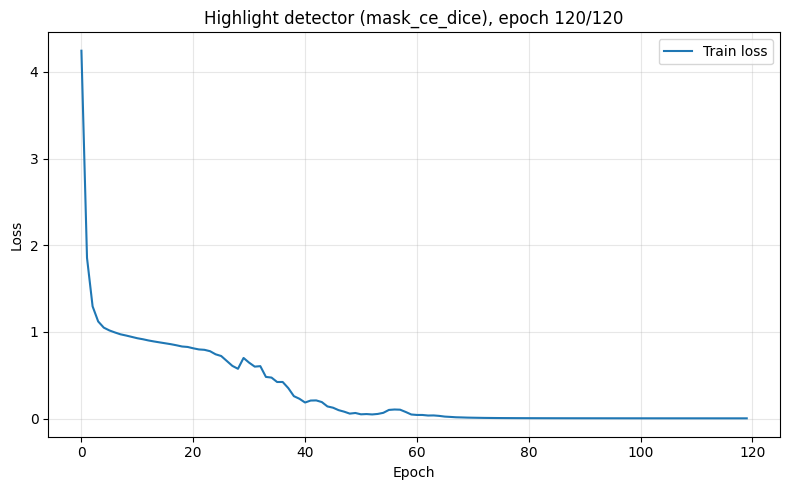

Epoch 120/120 | mode: mask_ce_dice | train: 0.002479 | elapsed: 12.2 min


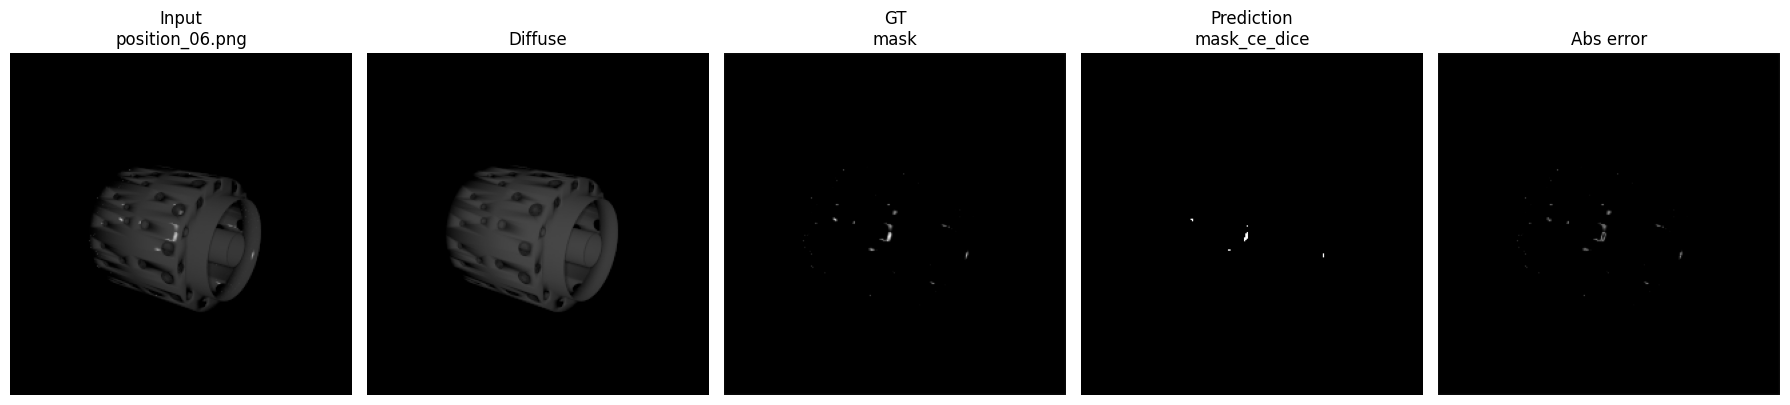

In [19]:
device = "cuda" if torch.cuda.is_available() else "cpu"

mask_model, mask_history = train_highlight_detector(
    train_loader=loader,
    val_loader=None,
    in_channels=3,
    lr=1e-3,
    epochs=120,
    device=device,
    detector_mode="mask_ce_dice",
    target_key="mask",
    highlight_weight=4.0,
    ce_weight=1.0,
    dice_weight=1.0,
    plot_every=1,
    preview_dataset=small_dataset,
    preview_every=5,
    save_best_path="weights/best_detector_mask_ce_dice.pth",
)


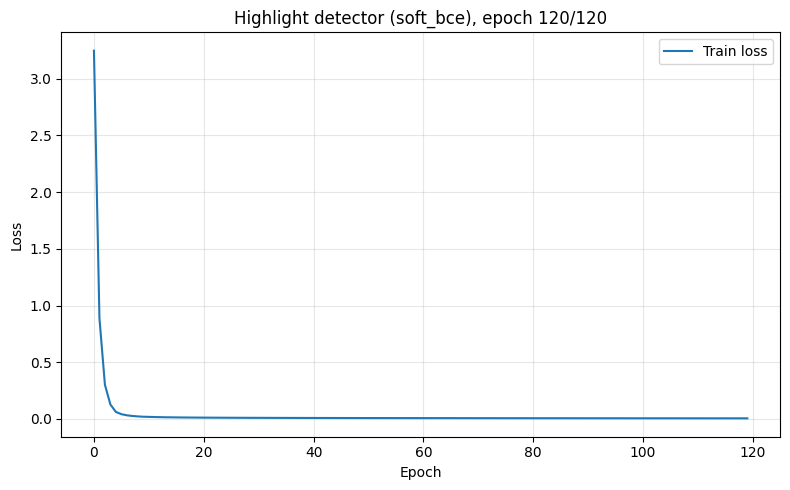

Epoch 120/120 | mode: soft_bce | train: 0.005350 | elapsed: 12.7 min


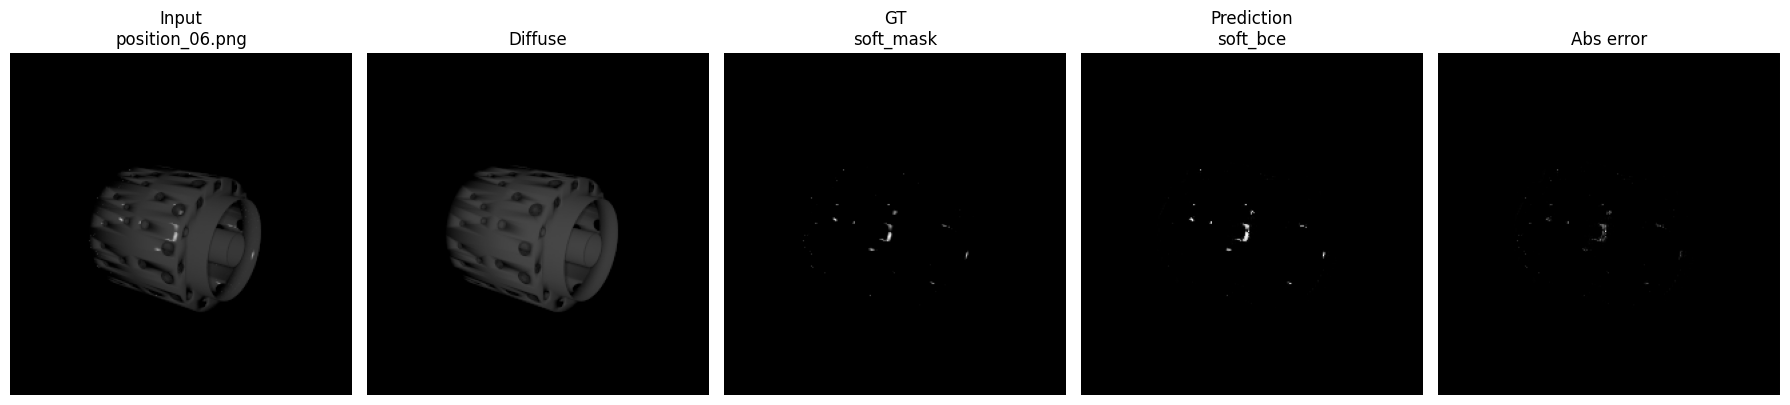

In [20]:
device = "cuda" if torch.cuda.is_available() else "cpu"

soft_model, soft_history = train_highlight_detector(
    train_loader=loader,
    val_loader=None,
    in_channels=3,
    lr=1e-3,
    epochs=120,
    device=device,
    detector_mode="soft_bce",
    target_key="soft_mask",
    soft_alpha=4.0,
    plot_every=1,
    preview_dataset=small_dataset,
    preview_every=5,
    save_best_path="weights/best_detector_soft_bce.pth",
)


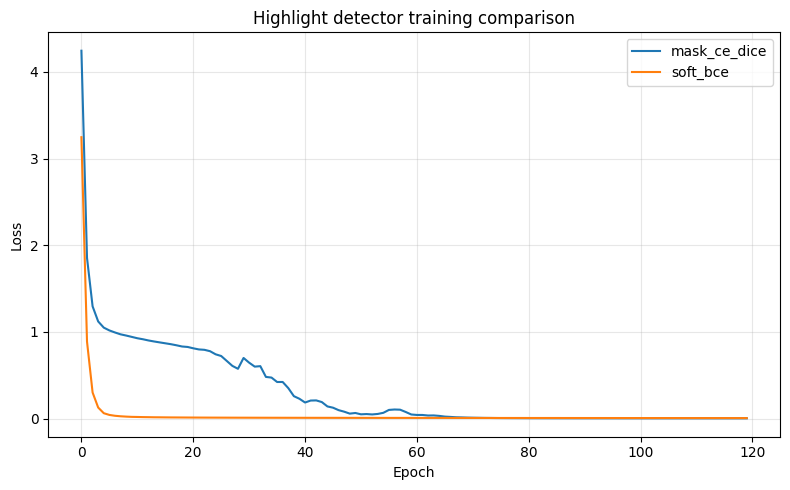

In [21]:
plt.figure(figsize=(8, 5))
plt.plot(mask_history["train_loss"], label="mask_ce_dice")
plt.plot(soft_history["train_loss"], label="soft_bce")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Highlight detector training comparison")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
